In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("osamaaslam86004/emnist-digits-balanced")

print("Path to dataset files:", path)

100%|██████████| 152M/152M [00:01<00:00, 114MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/osamaaslam86004/emnist-digits-balanced/versions/1


In [2]:
import os
import shutil
from PIL import Image

# Install Pillow if not already installed
!pip install Pillow


### Analyzing image properties

In [7]:
image_files = []

# Construct the correct path to the 'train' directory within the downloaded dataset
train_data_path = os.path.join(path, "train")

for root, _, files in os.walk(train_data_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
            image_files.append(os.path.join(root, file))

if not image_files:
    print(f"No image files found in {train_data_path}")
else:
    # Take the first image to inspect format and channels
    first_image_path = image_files[0]
    img = Image.open(first_image_path)
    print(f"Example image: {first_image_path}")
    print(f"Image format: {img.format}")
    print(f"Image mode (channels): {img.mode}") # 'RGB', 'L' (grayscale), etc.

    # Check dimensions
    dimensions = {}
    consistent_dimensions = True
    first_width, first_height = img.size

    for img_path in image_files:
        try:
            with Image.open(img_path) as current_img:
                current_width, current_height = current_img.size
                if (current_width, current_height) not in dimensions:
                    dimensions[(current_width, current_height)] = 0
                dimensions[(current_width, current_height)] += 1

                if (current_width, current_height) != (first_width, first_height):
                    consistent_dimensions = False
        except Exception as e:
            print(f"Could not open image {img_path}: {e}")

    print("\nDimension summary:")
    for dim, count in dimensions.items():
        print(f"  {dim[0]}x{dim[1]}: {count} images")

    if consistent_dimensions:
        print(f"\nAll images have the same dimensions: {first_width}x{first_height}")
    else:
        print("\nImages have varying dimensions.")

Example image: /root/.cache/kagglehub/datasets/osamaaslam86004/emnist-digits-balanced/versions/1/train/9/12559.png
Image format: PNG
Image mode (channels): L

Dimension summary:
  28x28: 240000 images

All images have the same dimensions: 28x28


### Resizing all images to 224x224

In [8]:
from PIL import Image
import os

def resize_image(image_path, size=(224, 224)):
    try:
        img = Image.open(image_path)
        # Resize with a high-quality filter for better results
        img_resized = img.resize(size, Image.LANCZOS)
        img_resized.save(image_path) # Overwrite the original image
    except Exception as e:
        print(f"Could not resize image {image_path}: {e}")

print(f"Resizing {len(image_files)} images to 224x224...")

for i, img_path in enumerate(image_files):
    resize_image(img_path)
    if (i + 1) % 10000 == 0:
        print(f"Processed {i + 1}/{len(image_files)} images...")

print("Image resizing complete.")

# Verify the dimensions of a sample image after resizing
if image_files:
    sample_image_path = image_files[0]
    with Image.open(sample_image_path) as img:
        print(f"\nSample image {os.path.basename(sample_image_path)} new dimensions: {img.size}")

Resizing 240000 images to 224x224...
Processed 10000/240000 images...
Processed 20000/240000 images...
Processed 30000/240000 images...
Processed 40000/240000 images...
Processed 50000/240000 images...
Processed 60000/240000 images...
Processed 70000/240000 images...
Processed 80000/240000 images...
Processed 90000/240000 images...
Processed 100000/240000 images...
Processed 110000/240000 images...
Processed 120000/240000 images...
Processed 130000/240000 images...
Processed 140000/240000 images...
Processed 150000/240000 images...
Processed 160000/240000 images...
Processed 170000/240000 images...
Processed 180000/240000 images...
Processed 190000/240000 images...
Processed 200000/240000 images...
Processed 210000/240000 images...
Processed 220000/240000 images...
Processed 230000/240000 images...
Processed 240000/240000 images...
Image resizing complete.

Sample image 12559.png new dimensions: (224, 224)


### Extracting masks for each digit class

In [9]:
import numpy as np

def extract_mask(image_path):
    """
    Extracts a binary mask from an image. Assumes digits are dark on a light background.
    """
    img = Image.open(image_path).convert('L') # Ensure grayscale
    # Convert image to numpy array for processing
    img_array = np.array(img)

    # Apply a simple threshold to create a binary mask
    # Adjust the threshold value as needed based on image characteristics.
    # Based on user feedback, if images produced black digits on white background,
    # this inversion (checking for >= threshold) will make digits white on a black background.
    threshold = 128 # Example threshold value
    mask_array = (img_array >= threshold).astype(np.uint8) * 255 # Convert to 0/255 for binary image (light pixels become white)

    return Image.fromarray(mask_array) # Return mask as a PIL Image, 'L' mode is inferred

output_mask_dir = "/content/masked_train"
os.makedirs(output_mask_dir, exist_ok=True)

print(f"Masks will be saved to: {output_mask_dir}")

# Process and save masks
for img_path in image_files:
    try:
        # Extract digit class from the image path (e.g., /content/synthetic_digits_v5/9/1196.png -> 9)
        digit_class = os.path.basename(os.path.dirname(img_path))

        # Create subdirectory for the digit class if it doesn't exist
        class_output_dir = os.path.join(output_mask_dir, digit_class)
        os.makedirs(class_output_dir, exist_ok=True)

        # Extract mask
        mask_img = extract_mask(img_path)

        # Define output path for the mask
        mask_filename = os.path.basename(img_path).replace('.png', '_mask.png') # Example naming
        mask_output_path = os.path.join(class_output_dir, mask_filename)

        # Save the mask
        mask_img.save(mask_output_path)

    except Exception as e:
        print(f"Could not process image {img_path} for mask extraction: {e}")

print("Mask extraction and saving complete.")

# Verify a few generated masks
print(f"\nContents of a sample digit class folder in {output_mask_dir}:")
sample_digit_class_path = os.path.join(output_mask_dir, '0') # Assuming '0' is a digit class
if os.path.exists(sample_digit_class_path):
    print(os.listdir(sample_digit_class_path)[:5]) # Print first 5 mask filenames
else:
    print(f"Directory {sample_digit_class_path} not found.")

Masks will be saved to: /content/masked_train
Mask extraction and saving complete.

Contents of a sample digit class folder in /content/masked_train:
['08807_mask.png', '01241_mask.png', '09487_mask.png', '04794_mask.png', '01032_mask.png']


In [10]:
import shutil
import google.colab.files

# Define the directory to be zipped and the output zip file name
folder_to_zip = "/content/masked_train"
output_zip_file = "/content/masked_train_archive"

# Create a zip archive
shutil.make_archive(output_zip_file, 'zip', folder_to_zip)

print(f"Successfully created zip archive: {output_zip_file}.zip")

# Trigger the download
google.colab.files.download(output_zip_file + '.zip')


Successfully created zip archive: /content/masked_train_archive.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Alternative: Traditional Image Processing for Masks and Bounding Boxes (Thresholding + Contours)

In [3]:
import cv2
import numpy as np
import pandas as pd
import os
from PIL import Image

output_traditional_masks_dir = "/content/traditional_masked_train"
output_traditional_bbox_file = "/content/traditional_bounding_boxes.csv"
os.makedirs(output_traditional_masks_dir, exist_ok=True)

# Re-initialize image_files to ensure it's defined
image_files = []
for root, _, files in os.walk("/content/masked_train"):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
            image_files.append(os.path.join(root, file))


bounding_box_data_traditional = []
problematic_files = [] # New list to store paths of files that cause errors

print(f"Processing {len(image_files)} images with traditional image processing...")

for i, img_path in enumerate(image_files):
    try:
        # Load image in grayscale
        image_cv = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if image_cv is None:
            print(f"Warning: Could not read image {img_path}. Skipping.")
            problematic_files.append((img_path, "Could not read image")) # Store file and error type
            continue # Skip to the next image

        # Apply adaptive thresholding to get a binary image
        # ADAPTIVE_THRESH_GAUSSIAN_C is often good for varying lighting
        # THRESH_BINARY_INV means pixels > threshold become 0 (black) and others become 255 (white)
        # This ensures white digits on a black background
        binary_img = cv2.adaptiveThreshold(image_cv, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                              cv2.THRESH_BINARY_INV, 11, 2) # Block size 11, C 2

        # Find contours
        # Handle different return signatures for cv2.findContours across OpenCV versions
        results = cv2.findContours(binary_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contours = [] # Initialize contours to empty list
        if len(results) >= 2:
            if len(results) == 3: # OpenCV 3.x and earlier: returns (image, contours, hierarchy)
                contours = results[1]
            else: # OpenCV 4.x and later: returns (contours, hierarchy)
                contours = results[0]
        else:
            print(f"Warning: cv2.findContours returned an unexpected number of values ({len(results)}) for {img_path}")

        bbox_coords = [0, 0, 0, 0] # Initialize with default values
        # Assuming there is one main digit, find the largest contour
        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(largest_contour)
            bbox_coords = [x, y, x + w, y + h]

        # Extract digit class and original filename
        digit_class = os.path.basename(os.path.dirname(img_path))
        original_filename = os.path.basename(img_path)

        # Save the binary mask (which is `binary_img`)
        class_output_dir = os.path.join(output_traditional_masks_dir, digit_class)
        os.makedirs(class_output_dir, exist_ok=True)
        mask_filename = original_filename.replace('.png', '_traditional_mask.png')
        mask_output_path = os.path.join(class_output_dir, mask_filename)
        Image.fromarray(binary_img).save(mask_output_path)

        # Store bounding box data
        bounding_box_data_traditional.append({
            'image_path': img_path,
            'digit_class': digit_class,
            'mask_path': mask_output_path,
            'bbox_xmin': bbox_coords[0],
            'bbox_ymin': bbox_coords[1],
            'bbox_xmax': bbox_coords[2],
            'bbox_ymax': bbox_coords[3]
        })

    except Exception as e:
        print(f"Could not process image {img_path} with traditional methods: {e}")
        problematic_files.append((img_path, str(e))) # Store file and the error message

    if (i + 1) % 10000 == 0: # Print progress every 10,000 images
        print(f"Processed {i + 1}/{len(image_files)} images...")

print("\nTraditional image processing complete.")

# Print problematic files summary
if problematic_files:
    print(f"\n{len(problematic_files)} images could not be processed. Here are some details:")
    for p_file, p_error in problematic_files[:10]: # Print first 10 for brevity
        print(f"  File: {p_file}, Error: {p_error}")
    if len(problematic_files) > 10:
        print("  ...")
else:
    print("\nAll images processed successfully with traditional methods.")

# Save bounding box data to a CSV file
bbox_df_traditional = pd.DataFrame(bounding_box_data_traditional)
bbox_df_traditional.to_csv(output_traditional_bbox_file, index=False)
print(f"Bounding box data saved to: {output_traditional_bbox_file}")

# Display first few rows of bounding box data
print("\nSample Traditional Bounding Box Data:")
display(bbox_df_traditional.head())

# Verify a few generated masks
print(f"\nContents of a sample digit class folder in {output_traditional_masks_dir}:")
sample_digit_class_path_traditional = os.path.join(output_traditional_masks_dir, '0') # Assuming '0' is a digit class
if os.path.exists(sample_digit_class_path_traditional):
    print(os.listdir(sample_digit_class_path_traditional)[:5]) # Print first 5 mask filenames
else:
    print(f"Directory {sample_digit_class_path_traditional} not found.")

Processing 240000 images with traditional image processing...
Processed 10000/240000 images...
Processed 20000/240000 images...
Processed 30000/240000 images...
Processed 40000/240000 images...
Processed 50000/240000 images...
Processed 60000/240000 images...
Processed 70000/240000 images...
Processed 80000/240000 images...
Processed 90000/240000 images...
Processed 100000/240000 images...
Processed 110000/240000 images...
Processed 120000/240000 images...
Processed 130000/240000 images...
Processed 140000/240000 images...
Processed 150000/240000 images...
Processed 160000/240000 images...
Processed 170000/240000 images...
Processed 180000/240000 images...
Processed 190000/240000 images...
Processed 200000/240000 images...
Processed 210000/240000 images...
Processed 220000/240000 images...
Processed 230000/240000 images...
Processed 240000/240000 images...

Traditional image processing complete.

All images processed successfully with traditional methods.
Bounding box data saved to: /c

,image_path,digit_class,mask_path,bbox_xmin,bbox_ymin,bbox_xmax,bbox_ymax
0,/content/masked_train/9/08807_mask.png,9,/content/traditional_masked_train/9/08807_mask...,47,13,175,213
1,/content/masked_train/9/01241_mask.png,9,/content/traditional_masked_train/9/01241_mask...,43,15,182,209
2,/content/masked_train/9/09487_mask.png,9,/content/traditional_masked_train/9/09487_mask...,49,16,180,209
3,/content/masked_train/9/04794_mask.png,9,/content/traditional_masked_train/9/04794_mask...,59,15,164,212
4,/content/masked_train/9/01032_mask.png,9,/content/traditional_masked_train/9/01032_mask...,45,16,180,208



Contents of a sample digit class folder in /content/traditional_masked_train:
['10811_mask_traditional_mask.png', '07542_mask_traditional_mask.png', '21211_mask_traditional_mask.png', '10067_mask_traditional_mask.png', '10084_mask_traditional_mask.png']


In [12]:
import shutil
import google.colab.files

# Define the directory to be zipped and the output zip file name
folder_to_zip_bbox = "/content/traditional_masked_train"
output_zip_file_bbox = "/content/traditional_masked_train_archive"

# Create a zip archive
shutil.make_archive(output_zip_file_bbox, 'zip', folder_to_zip_bbox)

print(f"Successfully created zip archive: {output_zip_file_bbox}.zip")

# Trigger the download
google.colab.files.download(output_zip_file_bbox + '.zip')

Successfully created zip archive: /content/traditional_masked_train_archive.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

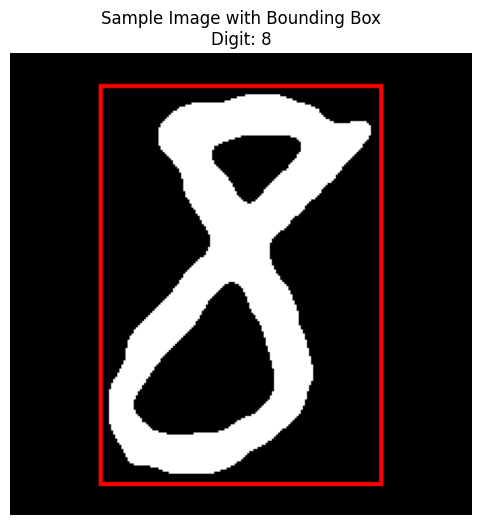

In [4]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import random

# Get a random sample from the bounding box data
sample_entry = bbox_df_traditional.sample(1).iloc[0]

image_path = sample_entry['image_path']
bbox_xmin = sample_entry['bbox_xmin']
bbox_ymin = sample_entry['bbox_ymin']
bbox_xmax = sample_entry['bbox_xmax']
bbox_ymax = sample_entry['bbox_ymax']

# Load the image
img = Image.open(image_path).convert('RGB') # Convert to RGB for drawing colored bounding box

# Create a drawing object
draw = ImageDraw.Draw(img)

# Draw the bounding box (xmin, ymin, xmax, ymax)
draw.rectangle([bbox_xmin, bbox_ymin, bbox_xmax, bbox_ymax], outline="red", width=2)

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Sample Image with Bounding Box\nDigit: {sample_entry['digit_class']}")
plt.axis('off')
plt.show()

In [ ]:
# Calculate width and height of bounding boxes
bbox_df_traditional['bbox_width'] = bbox_df_traditional['bbox_xmax'] - bbox_df_traditional['bbox_xmin']
bbox_df_traditional['bbox_height'] = bbox_df_traditional['bbox_ymax'] - bbox_df_traditional['bbox_ymin']

# Filter for zero-area bounding boxes
zero_area_bboxes = bbox_df_traditional[(bbox_df_traditional['bbox_width'] == 0) | (bbox_df_traditional['bbox_height'] == 0)]

print(f"Found {len(zero_area_bboxes)} images with zero-area bounding boxes.")

if not zero_area_bboxes.empty:
    print("Sample of images with zero-area bounding boxes:")
    display(zero_area_bboxes.head())
else:
    print("No images found with zero-area bounding boxes.")

In [ ]:
print(f"Original DataFrame size: {len(bbox_df_traditional)}")

# Filter out entries where either width or height is zero
bbox_df_traditional = bbox_df_traditional[(bbox_df_traditional['bbox_width'] > 0) & (bbox_df_traditional['bbox_height'] > 0)]

print(f"New DataFrame size after removing zero-area bounding boxes: {len(bbox_df_traditional)}")

# Display the head of the updated DataFrame
display(bbox_df_traditional.head())

In [ ]:
# Define the output path for the cleaned bounding box data
cleaned_bbox_output_file = "/content/cleaned_traditional_bounding_boxes.csv"

# Save the cleaned DataFrame to a new CSV file
bbox_df_traditional.to_csv(cleaned_bbox_output_file, index=False)

print(f"Cleaned bounding box data saved to: {cleaned_bbox_output_file}")

In [5]:
import os
import shutil
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import random

# Define the output directory for images with bounding boxes drawn on them
output_images_with_bbox_dir = "/content/images_with_drawn_bboxes"
os.makedirs(output_images_with_bbox_dir, exist_ok=True)

print(f"Saving images with drawn bounding boxes to: {output_images_with_bbox_dir}")

# Process and save images with bounding boxes
processed_count = 0
for index, row in bbox_df_traditional.iterrows():
    try:
        image_path = row['image_path']
        bbox_xmin = row['bbox_xmin']
        bbox_ymin = row['bbox_ymin']
        bbox_xmax = row['bbox_xmax']
        bbox_ymax = row['bbox_ymax']
        digit_class = row['digit_class']

        # Load the original image (which was the mask in the previous step, but is the target image here)
        # For this specific dataset, the 'image_path' in bbox_df_traditional points to the *masked* digit
        # If the user meant the *original* greyscale synthetic digit, this path needs adjustment.
        # Assuming 'image_path' refers to the actual image we want to draw on, which is the masked image for now.
        # If the original raw images are needed, the source path logic needs to change.
        img = Image.open(image_path).convert('RGB') # Convert to RGB for drawing colored bounding box

        draw = ImageDraw.Draw(img)

        # Draw the bounding box
        draw.rectangle([bbox_xmin, bbox_ymin, bbox_xmax, bbox_ymax], outline="red", width=2)

        # Create subdirectories for digit classes if they don't exist
        class_output_dir = os.path.join(output_images_with_bbox_dir, digit_class)
        os.makedirs(class_output_dir, exist_ok=True)

        # Save the image with the drawn bounding box
        output_filename = os.path.basename(image_path).replace('.png', '_bbox.png')
        output_filepath = os.path.join(class_output_dir, output_filename)
        img.save(output_filepath)
        processed_count += 1

    except Exception as e:
        print(f"Could not process image {image_path}: {e}")

    if (processed_count % 10000) == 0 and processed_count > 0:
        print(f"Processed {processed_count} images with bounding boxes...")

print(f"Successfully processed {processed_count} images with bounding boxes.")

# Verify a few generated images
print(f"\nContents of a sample digit class folder in {output_images_with_bbox_dir}:")
sample_digit_class_path = os.path.join(output_images_with_bbox_dir, '0') # Assuming '0' is a digit class
if os.path.exists(sample_digit_class_path):
    print(os.listdir(sample_digit_class_path)[:5]) # Print first 5 filenames
else:
    print(f"Directory {sample_digit_class_path} not found.")

Saving images with drawn bounding boxes to: /content/images_with_drawn_bboxes
Processed 10000 images with bounding boxes...
Processed 20000 images with bounding boxes...
Processed 30000 images with bounding boxes...
Processed 40000 images with bounding boxes...
Processed 50000 images with bounding boxes...
Processed 60000 images with bounding boxes...
Processed 70000 images with bounding boxes...
Processed 80000 images with bounding boxes...
Processed 90000 images with bounding boxes...
Processed 100000 images with bounding boxes...
Processed 110000 images with bounding boxes...
Processed 120000 images with bounding boxes...
Processed 130000 images with bounding boxes...
Processed 140000 images with bounding boxes...
Processed 150000 images with bounding boxes...
Processed 160000 images with bounding boxes...
Processed 170000 images with bounding boxes...
Processed 180000 images with bounding boxes...
Processed 190000 images with bounding boxes...
Processed 200000 images with bounding 

### Zipping Images with Drawn Bounding Boxes

In [ ]:
import shutil
import google.colab.files

# Define the directory to be zipped and the output zip file name
folder_to_zip_annotated = "/content/images_with_drawn_bboxes"
output_zip_file_annotated = "/content/images_with_drawn_bboxes_archive__"

# Create a zip archive
shutil.make_archive(output_zip_file_annotated, 'zip', folder_to_zip_annotated)

print(f"Successfully created zip archive: {output_zip_file_annotated}.zip")

### Moving the archive to Google Drive

In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define the source and destination paths
source_zip_path = output_zip_file_annotated + '.zip'
destination_drive_path = '/content/drive/MyDrive/' + os.path.basename(source_zip_path)

# Move the zip file to Google Drive
shutil.move(source_zip_path, destination_drive_path)

print(f"Successfully moved {os.path.basename(source_zip_path)} to {destination_drive_path}")